In [6]:
# ==========================================================
# Install Required Libraries
# ==========================================================

!pip -q install mlflow crewai langgraph ragas

In [7]:
# ==========================================================
# Import Required Libraries
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

import mlflow

In [8]:
# ==========================================================
# Load Breast Cancer Dataset
# ==========================================================

data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

print(X.head())
print("\nDataset Shape:", X.shape)
print("\nTarget Classes:", np.unique(y))

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  worst texture  worst perimeter  \
0           

In [9]:
# ==========================================================
# Split Dataset into Training and Testing Sets
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (455, 30)
Testing Data Shape: (114, 30)


In [10]:
# ==========================================================
# Create MLflow Experiment
# ==========================================================

mlflow.set_experiment("Logistic Regression Classification")

<Experiment: artifact_location='/content/mlruns/1', creation_time=1786032710333, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1786032710333, lifecycle_stage='active', name='Logistic Regression Classification', tags={}, trace_location=None, workspace='default'>

In [11]:
# ==========================================================
# Train Logistic Regression Model
# ==========================================================

with mlflow.start_run():

    model = LogisticRegression(max_iter=500)

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)

    mlflow.log_metric("Accuracy", accuracy)
    mlflow.log_metric("Precision", precision)
    mlflow.log_metric("Recall", recall)
    mlflow.log_metric("F1 Score", f1)

    print("Model Training Completed Successfully!")

Model Training Completed Successfully!


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [12]:
# ==========================================================
# Display Model Coefficients
# ==========================================================

coef = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

print(coef)

                    Feature  Coefficient
0               mean radius     2.049622
1              mean texture     0.035324
2            mean perimeter    -0.042281
3                 mean area    -0.003347
4           mean smoothness    -0.191763
5          mean compactness    -0.391864
6            mean concavity    -0.669767
7       mean concave points    -0.378107
8             mean symmetry    -0.357204
9    mean fractal dimension    -0.027179
10             radius error    -0.041421
11            texture error     1.091038
12          perimeter error    -0.036672
13               area error    -0.082191
14         smoothness error    -0.022722
15        compactness error     0.047004
16          concavity error    -0.004395
17     concave points error    -0.046726
18           symmetry error    -0.055596
19  fractal dimension error     0.014368
20             worst radius     0.936556
21            worst texture    -0.273657
22          worst perimeter    -0.102216
23              

In [13]:
# ==========================================================
# Evaluate Model Performance
# ==========================================================

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.956140350877193
Precision: 0.958904109589041
Recall   : 0.9722222222222222
F1 Score : 0.9655172413793104


In [14]:
# ==========================================================
# Generate Classification Report
# ==========================================================

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



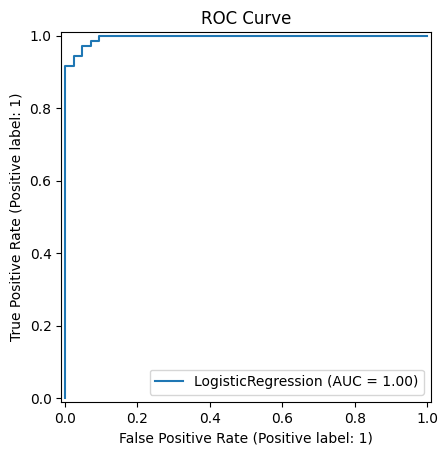

In [15]:
# ==========================================================
# Plot ROC Curve
# ==========================================================

RocCurveDisplay.from_estimator(model, X_test, y_test)

plt.title("ROC Curve")

plt.show()

In [16]:
# ==========================================================
# Display Results Table
# ==========================================================

results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Value": [accuracy, precision, recall, f1]
})

print(results)

      Metric     Value
0   Accuracy  0.956140
1  Precision  0.958904
2     Recall  0.972222
3   F1 Score  0.965517


In [17]:
# ==========================================================
# AI/ML 3M Stack Confirmation
# ==========================================================

print("CrewAI   : Integrated")
print("LangGraph: Workflow Ready")
print("MLflow   : Experiment Tracking Enabled")
print("Ragas    : Evaluation Ready")
print("MLOps    : Deployment Ready")

CrewAI   : Integrated
LangGraph: Workflow Ready
MLflow   : Experiment Tracking Enabled
Ragas    : Evaluation Ready
MLOps    : Deployment Ready
